In [2]:
### data loader 
### Converter

import numpy as np

def converter_b2f(bi, lx, ly, s):
    """
    generate the data from bit string to defined array file
    """
    num = []   # matter occupations
    Input = [] # link values

    for i, char in enumerate(bi):  
        if i % 3 == 0:
            num.append(float(char))  # Convert to real number
        else:
            Input.append(char)

    hor = []
    ver = []
    for i in range(len(Input) // 2):
        h = Input[2 * i]
        v = Input[2 * i + 1]
        if s == 1/2:
            hor.append(-0.5 if h == '0' else 0.5)
            ver.append(-0.5 if v == '0' else 0.5)
        else:
            hor.append(-1 if h == '0' else (1 if h == '2' else 0))
            ver.append(-1 if v == '0' else (1 if v == '2' else 0))

    hor = np.array(hor).reshape(lx, ly).T
    ver = np.array(ver).reshape(lx, ly).T
    num = np.array(num).reshape(lx, ly).T  # already float

    return num, ver, hor

def converter_f2s(Type, Input, s):
    """
    generate the data from defined array file to bit string and strong for mptoolkit
    """
    if Type == 'binary2string':
        output = []
        for i in range(len(Input) // 3):
            if s == 1/2:  
                val1 = '0.5' if Input[3*i+1] == '1' else '-0.5'
                val2 = '0.5' if Input[3*i+2] == '1' else '-0.5'
            else:
                val1 = '-1' if Input[3*i+1] == '0' else ('1' if Input[3*i+1] == '2' else '0')
                val2 = '-1' if Input[3*i+2] == '0' else ('1' if Input[3*i+2] == '2' else '0')
            output.append(f"empty:{val1}:{val2}")
        return ':'.join(output) + ':' 



    elif Type == 'file2binary':
        two_flat = Input[1].T.flatten()
        three_flat = Input[2].T.flatten()
        one_flat =  Input[0].T.flatten()
        binary = []
        for one, two, three in zip(one_flat, two_flat, three_flat):
            if s == 1/2:
                binary.append('0' if one == 0 else '1')
                binary.append('0' if two == -0.5 else '1')
                binary.append('0' if three == -0.5 else '1')
            else:
                binary.append('0' if one == 0 else '1')
                binary.append('0' if two == -1 else ('2' if two == 1 else '1'))
                binary.append('0' if three == -1 else ('2' if three == 1 else '1'))
            
        return ''.join(binary)

    else:
        raise ValueError(f"Unknown Type: {Type}")
            
def converter_full(bi, ly, lx):
    num = []   # matter occupations
    Input = [] # link values

    for i, char in enumerate(bi):
        if i % 3 == 0:
                num.append(float(char))# Convert to real number
        else:
            Input.append(char)

    hor = []
    ver = []
    for i in range(len(Input) // 2):
        h = Input[2 * i]
        v = Input[2 * i + 1]
        hor.append(-0.5 if h == '0' else 0.5)
        ver.append(-0.5 if v == '0' else 0.5)

    hor = np.array(hor).reshape(lx, ly).T
    ver = np.array(ver).reshape(lx, ly).T
    num = np.array(num).reshape(lx, ly).T  # already float

    return num, ver, hor

def converter_half(Type, Input, x, y):
    if Type == 'binary2string':
        output = []
        for i in range(len(Input) // 3):
            if i//y%2 == 0:
                val0 = 'single' if int(Input[3*i]) + ((-1)**(i%2+1)+1)/2 == 1 else 'empty'
            else:
                val0 = 'empty' if int(Input[3*i]) + ((-1)**(i%2+1)+1)/2 == 1 else 'single'
            val1 = '0.5' if Input[3*i+1] == '1' else '-0.5'
            val2 = '0.5' if Input[3*i+2] == '1' else '-0.5'
            output.append(f"{val0}:{val1}:{val2}")
        return ':'.join(output) + ':' 



    elif Type == 'file2binary':
        two_flat = Input[0].flatten()
        three_flat = Input[1].flatten()
        binary = []
        for two, three in zip(two_flat, three_flat):
            binary.append('0' if two == -0.5 else '1')
            binary.append('0' if three == -0.5 else '1')
            
        return ''.join(binary)

    else:
        raise ValueError(f"Unknown Type: {Type}")



def inverse_converter_full(num, ver, hor):
    """
    Reconstructs the flattened bitstring from matter, vertical, and horizontal arrays.

    Each site is encoded as:
        [matter][horizontal][vertical]

    Assumes:
        - matter: 0 or 1
        - hor, ver: -0.5 or 0.5 → mapped to '0' or '1'

    Parameters:
        num (array): (ly x lx) array of matter occupation
        ver (array): (ly x lx) array of vertical link values
        hor (array): (ly x lx) array of horizontal link values

    Returns:
        bitstring (str): flattened string of length 3 * lx * ly
    """
    ly, lx = num.shape
    s = ""

    for x in range(lx):
        for y in range(ly):
            matter_char = str(int(num[y, x]))
            hor_char = '0' if hor[y, x] == -0.5 else '1'
            ver_char = '0' if ver[y, x] == -0.5 else '1'
            s += matter_char + hor_char + ver_char

    return s

In [3]:
### plotter


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec


def plot_lattice_charge(ax, Lx, Ly, site_val, link_values_x, link_values_y, t, m, J, g, chi, pp, pe, s):
    x, y = np.meshgrid(np.arange(Lx), np.arange(Ly))
    if s == 1/2: 
        link_values_x = np.abs(link_values_x-1/2)
        link_values_y = np.abs(link_values_y-1/2)
    if s == 1: 
        link_values_x = link_values_x**2
        link_values_y = link_values_y**2
    # === Normalize ===
    site_norm = Normalize(vmin=-1, vmax=1)
    link_norm = Normalize(vmin=0, vmax=1)
    if len(site_val) == 0:
        site_val = np.zeros((Ly, Lx))
        for xx in range(Lx):
            for yy in range(Ly):
                site_val[yy][xx] = site_val[yy][xx] + (1/2) + (1/2)*(-1)**(xx+yy+1)
    # --- Plot horizontal links ---
    segments_x = []
    colors_x = []
    for i in range(Ly):
        for j in range(Lx):
            p1 = (j, i)
            p2 = (j + 1, i)
            segments_x.append([p1, p2])
            colors_x.append(link_values_x[i][j])
    lc_x = LineCollection(
        segments_x, 
        cmap='Greys', 
        array=np.array(colors_x), 
        norm=link_norm,
        linewidths=2
    )
    ax.add_collection(lc_x)

    
    # --- Plot vertical links ---
    segments_y = []
    colors_y = []
    for i in range(Ly):
        for j in range(Lx):
            p1 = (j, i)
            p2 = (j, i + 1)
            segments_y.append([p1, p2])
            colors_y.append(link_values_y[i][j])
    
    lc_y = LineCollection(
        segments_y, 
        cmap='Greys', 
        array=np.array(colors_y), 
        norm=link_norm,
        linewidths=2
    )
    ax.add_collection(lc_y)

    # --- Plot site values --- 
        

    for xx in range(Lx):
        for yy in range(Ly):
            site_val[yy][xx] = site_val[yy][xx] + (-1/2) + (1/2)*(-1)**(xx+yy) 
        
    site_scatter = ax.scatter(
    x, y, 
    c=site_val.flatten(),  # Flatten site values to match (x, y) shape
    cmap='coolwarm', 
    norm=site_norm,
    s=100, 
    zorder=2
    )

    # Plot layout settings
    ax.set_aspect('equal')
    ax.set_xticks(range(Lx))
    ax.set_yticks(range(Ly))
    ax.set_title(rf't={t}, m = {m}, J = {J}, g = {g}, $\chi$ = {chi}')

     # --- Add hollow dots ---
    ax.scatter(pp[0], pp[1], facecolors='none', edgecolors='red', s=200, linewidths=2, zorder=3)
    ax.scatter(pe[0], pe[1], facecolors='none', edgecolors='blue', s=200, linewidths=2, zorder=3)
 
    return site_scatter, lc_x, lc_y

def plot_lattice_fermion(ax, Lx, Ly, site_val, link_values_x, link_values_y, t, m, J, g, chi, pp, pe, s):
    x, y = np.meshgrid(np.arange(Lx), np.arange(Ly))
    # === Normalize ===
    site_norm = Normalize(vmin=0, vmax=1)
    if s == 1:
        link_norm = Normalize(vmin=-1, vmax=1)
    if s == 1/2:
        link_norm = Normalize(vmin=-1/2, vmax=1/2)
    if len(site_val) == 0:
        site_val = np.zeros((Ly, Lx))
        for xx in range(Lx):
            for yy in range(Ly):
                site_val[yy][xx] = site_val[yy][xx] + (1/2) + (1/2)*(-1)**(xx+yy+1)
    # --- Plot horizontal links ---
    segments_x = []
    colors_x = []
    for i in range(Ly):
        for j in range(Lx):
            p1 = (j, i)
            p2 = (j + 1, i)
            segments_x.append([p1, p2])
            colors_x.append(link_values_x[i][j])
    lc_x = LineCollection(
        segments_x, 
        cmap='coolwarm', 
        array=np.array(colors_x), 
        norm=link_norm,
        linewidths=2
    )
    ax.add_collection(lc_x)

    
    # --- Plot vertical links ---
    segments_y = []
    colors_y = []
    for i in range(Ly):
        for j in range(Lx):
            p1 = (j, i)
            p2 = (j, i + 1)
            segments_y.append([p1, p2])
            colors_y.append(link_values_y[i][j])
    
    lc_y = LineCollection(
        segments_y, 
        cmap='coolwarm', 
        array=np.array(colors_y), 
        norm=link_norm,
        linewidths=2
    )
    ax.add_collection(lc_y)

    # --- Plot site values ---
    if len(site_val) == 0:
        site_val = np.ones((Ly, Lx))
        for xx in range(Lx):
            for yy in range(Ly):
                site_val[yy][xx] = site_val[yy][xx] + (1/2) + (1/2)*(-1)**(xx+yy+1) 

    site_scatter = ax.scatter(
    x, y, 
    c=site_val.flatten(),  # Flatten site values to match (x, y) shape
    cmap='Greys', 
    norm=site_norm,
    s=100, 
    zorder=2
    )

    # Plot layout settings
    ax.set_aspect('equal')
    ax.set_xticks(range(Lx))
    ax.set_yticks(range(Ly))
    if t == '/':
        pass
    else:
        ax.set_title(rf't={t}, m = {m}, J = {J}, g = {g}, $\chi$ = {chi}')

     # --- Add hollow dots ---
    ax.scatter(pp[0], pp[1], facecolors='none', edgecolors='red', s=200, linewidths=2, zorder=3)
    ax.scatter(pe[0], pe[1], facecolors='none', edgecolors='blue', s=200, linewidths=2, zorder=3)
 
    return site_scatter, lc_x, lc_y

In [4]:

### krylov generator 

### 2D qlm
def plaquette_checker(bitstring, Lx, Ly, S, conserveenergy, pbc=False):
    """
    Plaquette checker for arbitrary spin-S quantum link models with dynamical matter.

    Input format:
        Each site is represented by 3 characters:
            [matter][right_link][left_link]
        - matter: 0 or 1 (not used in plaquette action here)
        - right_link and left_link: integers from 0 to 2S
        Total string length = 3 * Lx * Ly

    Parameters:
        bitstring (str): string representing the state.
        Lx, Ly (int): lattice dimensions.
        S (int or float): spin value (e.g. 0.5, 1, 1.5, ...).
        conserveenergy (bool): if True, only include plaquette actions
                               that conserve the number of zero links.

    Returns:
        surviving_plaquettes (list): list of tuples
            (j, indices, direction)
            where:
              - j: flattened site index (top-left site of plaquette)
              - indices: list of 4 link indices in bitstring
              - direction: 'forward' or 'backward'
    """
    max_m = int(2 * S)
    surviving_plaquettes = []

    def site_index(x, y):
        """Return flattened site index"""
        return x * Ly + y

    def bit_indices(x, y):
        """
        Given site (x, y), return:
        - matter index
        - right link index
        - left link index
        """
        base = 3 * site_index(x, y)
        return base, base + 1, base + 2
    
    if pbc == True:
        DX = Lx
        DY = Ly
    else:
        DX = Lx - 1
        DY = Ly - 1

    for x in range(DX):
        for y in range(DY):
            try:
                # Plaquette sites A, B, C, D in clockwise order
                # A = (x, y), B = (x, y+1), C = (x+1, y+1), D = (x+1, y)
                # Links used: A.right, B.right, C.left, D.left
                if x == Lx-1 and y < Ly-1:
                    _, _, A_up = bit_indices(x, y)
                    _, B_right, _ = bit_indices(x, y + 1)
                    _, A_right, _ = bit_indices(x , y)
                    _, _, C_up = bit_indices(0, y)
                
                if x < Lx-1 and y == Ly-1:
                    _, _, A_up = bit_indices(x, y)
                    _, B_right, _ = bit_indices(x, 0)
                    _, A_right, _ = bit_indices(x , y)
                    _, _, C_up = bit_indices(x + 1, y)

                if x == Lx-1 and y == Ly-1:
                    _, _, A_up = bit_indices(x, y)
                    _, B_right, _ = bit_indices(x, 0)
                    _, A_right, _ = bit_indices(x , y)
                    _, _, C_up = bit_indices(0, y)
                
                if x < Lx-1 and y < Ly-1:
                    _, _, A_up = bit_indices(x, y)
                    _, B_right, _ = bit_indices(x, y + 1)
                    _, A_right, _ = bit_indices(x , y)
                    _, _, C_up = bit_indices(x + 1, y)

                indices = [A_up, B_right, A_right, C_up]
                ms = [int(bitstring[idx]) for idx in indices]
                n_zero_before = sum(m == 0 for m in ms)

                # === Forward plaquette: S+ S+ S- S-
                forward = (ms[0] < max_m and
                           ms[1] < max_m and
                           ms[2] > 0     and
                           ms[3] > 0)

                if forward:
                    ms_after = [ms[0]+1, ms[1]+1, ms[2]-1, ms[3]-1]
                    n_zero_after = sum(m == 0 for m in ms_after)

                    if (not conserveenergy) or (n_zero_after == n_zero_before):
                        surviving_plaquettes.append((site_index(x, y), indices, 'forward'))

                # === Backward plaquette: S- S- S+ S+
                backward = (ms[0] > 0     and
                            ms[1] > 0     and
                            ms[2] < max_m and
                            ms[3] < max_m)

                if backward:
                    ms_after = [ms[0]-1, ms[1]-1, ms[2]+1, ms[3]+1]
                    n_zero_after = sum(m == 0 for m in ms_after)

                    if (not conserveenergy) or (n_zero_after == n_zero_before):
                        surviving_plaquettes.append((site_index(x, y), indices, 'backward'))

            except IndexError:
                continue  # Skip if indices go out of range

    return surviving_plaquettes


def apply_plaquette_spinS_fast(state, indices, direction):
    """
    Fast plaquette operator application for spin-S models.
    Assumes pre-filtered valid plaquette actions.

    Parameters:
        state (str or list): current state.
        indices (list of int): indices of plaquette links.
        direction (str): 'forward' or 'backward'.

    Returns:
        new_state (list of int): updated state.
    """
    # Convert to list if input is a string
    if isinstance(state, str):
        new_state = list(state)
    else:
        new_state = state.copy()

    if direction == 'forward':
        new_state[indices[0]] = str(int(new_state[indices[0]]) + 1)
        new_state[indices[1]] = str(int(new_state[indices[1]]) + 1)
        new_state[indices[2]] = str(int(new_state[indices[2]]) - 1)
        new_state[indices[3]] = str(int(new_state[indices[3]]) - 1)

    elif direction == 'backward':
        new_state[indices[0]] = str(int(new_state[indices[0]]) - 1)
        new_state[indices[1]] = str(int(new_state[indices[1]]) - 1)
        new_state[indices[2]] = str(int(new_state[indices[2]]) + 1)
        new_state[indices[3]] = str(int(new_state[indices[3]]) + 1)
    new_state = ''.join(new_state)
    return new_state

def hopping_checker(bitstring, b_int, Lx, Ly, S, ev, m, g, pbc = False):
    """
    Checks for energy-conserving hoppings of matter in 4 directions.

    Parameters:
        bitstring (str): current configuration
        b_int (str): initial reference configuration
        Lx, Ly (int): lattice size
        S (float): spin value
        ev (float): allowed energy deviation
        m, J (float): onsite mass and link coupling

    Returns:
        surviving_hops (list): list of (site_index, involved_indices, direction)
    """
    surviving_hops = []
    max_m = 2*S

    def compute_energy(bi, lx, ly, m, g):
        num, ver, hor = converter_b2f(bi, lx, ly, S)
        onsite_energy = m * sum(num[y, x] * (-1) ** (x + y) for x in range(lx) for y in range(ly))
        if S == 1/2:
            link_energy = g * (np.sum(hor) + np.sum(ver))
        else:
            link_energy = g**2 * (np.sum(hor**2) + np.sum(ver**2))
        return onsite_energy + link_energy

    def delta_energy(ms, msa, x, y, m, g):
        s1 = (-1) ** (x + y)
        s2 = (-1) ** (x + y + 1)
        if S == 1/2:
            return (
                (msa[0] * s1 + msa[3] * s2 + msa[4] * s2) * m
                + msa[1] * g + msa[2] * g
                - (ms[0] * s1 + ms[3] * s2 + ms[4] * s2) * m
                - ms[1] * g - ms[2] * g
            )
        else:
            return (
                (msa[0] * s1 + msa[3] * s2 + msa[4] * s2) * m
                +  (msa[1]-1)**2 * g**2 + (msa[2]-1)**2 * g**2
                - (ms[0] * s1 + ms[3] * s2 + ms[4] * s2) * m
                - (ms[1]-1)**2 * g**2 - (ms[2]-1)**2 * g**2
            )

    def site_index(x, y):
        return x * Ly + y

    def bit_indices(x, y):
        base = 3 * site_index(x, y)
        return base, base + 1, base + 2  # matter, right, up

    E_int = compute_energy(b_int, Lx, Ly, m, g)
    E_current = compute_energy(bitstring, Lx, Ly, m, g)

    for x in range(Lx):
        for y in range(Ly):
            base, r, u = bit_indices(x, y)
            if pbc == True:
                base_up, _, _ = bit_indices(x, y + 1) if y + 1 < Ly else  bit_indices(x, 0)
                base_right, _, _ = bit_indices(x + 1, y) if x + 1 < Lx else bit_indices(0, y)
            else:
                base_up, _, _ = bit_indices(x, y + 1) if y + 1 < Ly else  (np.inf, 0, 0)
                base_right, _, _ = bit_indices(x + 1, y) if x + 1 < Lx else (np.inf, 0, 0)

            indices = [base, r, u, base_up, base_right]
            ms = []
            for idx in indices:
                ms.append(int(bitstring[idx]) if idx < np.inf else 100000)

            if S == 1/2:
                # === Hop up ===
                if ms[0] == 1 and ms[3] == 0 and ms[2] == 1:
                    msa = [ms[0] - 1, ms[1], (ms[2] + 1) % 2, ms[3] + 1, ms[4]]
                    dE = delta_energy(ms, msa, x, y, m, g)
                    if abs(E_int - E_current + dE) < ev:
                        surviving_hops.append((site_index(x, y), indices, 'hop_up'))
    
                # === Hop down ===
             
                if ms[0] == 0 and ms[3] == 1 and ms[2] == 0:
                    msa = [ms[0] + 1, ms[1], (ms[2] + 1) % 2, ms[3] - 1, ms[4]]
                    dE = delta_energy(ms, msa, x, y, m, g)
                    if abs(E_int - E_current + dE) < ev:
                        surviving_hops.append((site_index(x, y), indices, 'hop_down'))
    
                # === Hop left ===
                if ms[0] == 0 and ms[4] == 1 and ms[1] == 0:
                    msa = [ms[0] + 1, (ms[1] + 1) % 2, ms[2], ms[3], ms[4] - 1]
                    dE = delta_energy(ms, msa, x, y, m, g)
                    if abs(E_int - E_current + dE) < ev:
                        surviving_hops.append((site_index(x, y), indices, 'hop_left'))
    
                # === Hop right ===
                if ms[0] == 1 and ms[4] == 0 and ms[1] == 1:
                    msa = [ms[0] - 1, (ms[1] + 1) % 2, ms[2], ms[3], ms[4] + 1]
                    dE = delta_energy(ms, msa, x, y, m, g)
                    if abs(E_int - E_current + dE) < ev:
                        surviving_hops.append((site_index(x, y), indices, 'hop_right'))
            else:
                 # === Hop up ===
                if ms[0] == 1 and ms[3] == 0 and ms[2] > 0:
                    msa = [ms[0] - 1, ms[1], (ms[2] - 1), ms[3] + 1, ms[4]]
                    dE = delta_energy(ms, msa, x, y, m, g)
                    if abs(E_int - E_current + dE) < ev:
                        surviving_hops.append((site_index(x, y), indices, 'hop_up'))
    
                # === Hop down ===
                if ms[0] == 0 and ms[3] == 1 and ms[2] <  max_m:
                    msa = [ms[0] + 1, ms[1], (ms[2] + 1), ms[3] - 1, ms[4]]
                    dE = delta_energy(ms, msa, x, y, m, g)
                    if abs(E_int - E_current + dE) < ev:
                        surviving_hops.append((site_index(x, y), indices, 'hop_down'))
    
                # === Hop left ===
                if ms[0] == 0 and ms[4] == 1 and ms[1] < max_m:
                    msa = [ms[0] + 1, (ms[1] + 1), ms[2], ms[3], ms[4] - 1]
                    dE = delta_energy(ms, msa, x, y, m, g)
                    if abs(E_int - E_current + dE) < ev:
                        surviving_hops.append((site_index(x, y), indices, 'hop_left'))
    
                # === Hop right ===
                if ms[0] == 1 and ms[4] == 0 and ms[1] > 0:
                    msa = [ms[0] - 1, (ms[1] - 1), ms[2], ms[3], ms[4] + 1]
                    dE = delta_energy(ms, msa, x, y, m, g)
                    if abs(E_int - E_current + dE) < ev:
                        surviving_hops.append((site_index(x, y), indices, 'hop_right'))

    return surviving_hops


def apply_hopping_spinS_fast(state, indices, direction, S):
    """
    Apply a hopping operation to the state.

    Parameters:
        state (str or list): current state string or list.
        indices (list of int): [matter, right, up, target_matter, target_link]
        direction (str): one of 'hop_up', 'hop_down', 'hop_left', 'hop_right'

    Returns:
        new_state (str): updated state after hopping.
    """
    if isinstance(state, str):
        new_state = list(state)
    else:
        new_state = state.copy()

    m, r, u, tm, tl = indices  # unpack

    if S == 1/2:
        if direction == 'hop_up' or direction == 'hop_down':
            # Flip vertical link (`u`) and modify vertical connector `tm`
            new_state[m] = str(int(new_state[m]) - 1 if direction == 'hop_up' else int(new_state[m]) + 1)
            new_state[u] = str((int(new_state[u]) + 1) % 2)  # toggle link
            new_state[tm] = str(int(new_state[tm]) + 1 if direction == 'hop_up' else int(new_state[tm]) - 1)
    
        elif direction == 'hop_right' or direction == 'hop_left':
            # Flip horizontal link (`r`) and modify horizontal connector `tl`
            new_state[m] = str(int(new_state[m]) - 1 if direction == 'hop_right' else int(new_state[m]) + 1)
            new_state[r] = str((int(new_state[r]) + 1) % 2)  # toggle link
            new_state[tl] = str(int(new_state[tl]) + 1 if direction == 'hop_right' else int(new_state[tl]) - 1)
        return ''.join(new_state)
    if S == 1:
        if direction == 'hop_up' or direction == 'hop_down':
            # Flip vertical link (`u`) and modify vertical connector `tm`
            new_state[m] = str(int(new_state[m]) - 1 if direction == 'hop_up' else int(new_state[m]) + 1)
            new_state[u] = str(int(new_state[u]) - 1 if direction == 'hop_up' else int(new_state[u]) + 1)  # toggle link
            new_state[tm] = str(int(new_state[tm]) + 1 if direction == 'hop_up' else int(new_state[tm]) - 1)
    
        elif direction == 'hop_right' or direction == 'hop_left':
            # Flip horizontal link (`r`) and modify horizontal connector `tl`
            new_state[m] = str(int(new_state[m]) - 1 if direction == 'hop_right' else int(new_state[m]) + 1)
            new_state[r] = str(int(new_state[r]) - 1 if direction == 'hop_right' else int(new_state[r]) + 1)  # toggle link
            new_state[tl] = str(int(new_state[tl]) + 1 if direction == 'hop_right' else int(new_state[tl]) - 1)

        return ''.join(new_state)






from collections import deque

import sys
from collections import deque

from collections import deque
from IPython.display import clear_output

def generate_all_reachable_configs(
    initial_state, Lx, Ly, S, conserveenergy,
    dynamics='plaquette', m=1.0, g=1.0, ev=1e-6, pbc = False
):
    """
    Jupyter-friendly BFS:
    - uses clear_output(wait=True) to "delete then print"
    - refreshes dynamically only when queue/states change enough (prevents IOPub flooding)
    """

    seen_states = {initial_state}                 # O(1) membership
    all_states_with_cycle = {(initial_state, 0)}  # keep (state, cycle)
    checked_states = set()
    queue = deque([(initial_state, 0)])

    step = 0
    max_queue = 1

    # dynamic refresh control (no print_every)
    last_q = 0
    last_states = 1
    next_q_trigger = 1
    next_states_trigger = 2

    while queue:
        step += 1

        qlen = len(queue)
        nstates = len(seen_states)
        max_queue = max(max_queue, qlen)

        # ---- dynamic refresh (only when growth crosses thresholds) ----
        # Queue trigger: when queue grows by ~25% or shrinks a lot (new phase)
        # States trigger: when states reach 2x milestones (2,4,8,16,...)
        do_refresh = False

        if qlen >= next_q_trigger or qlen <= max(1, last_q // 2):
            do_refresh = True
            next_q_trigger = max(qlen + 1, int(qlen * 1.25) + 1)

        if nstates >= next_states_trigger:
            do_refresh = True
            while next_states_trigger <= nstates:
                next_states_trigger *= 2

        if do_refresh:
            clear_output(wait=True)
            print(
                f"[Step {step}] "
                f"Queue={qlen} | "
                f"AllStates={nstates} | "
                f"Checked={len(checked_states)} | "
                f"MaxQueue={max_queue}"
            )
            last_q = qlen
            last_states = nstates

        current_state, current_cycle = queue.popleft()
        if current_state in checked_states:
            continue
        checked_states.add(current_state)

        # --- Plaquette dynamics ---
        if dynamics in ("plaquette", "both"):
            for _, indices, direction in plaquette_checker(current_state, Lx, Ly, S, conserveenergy, pbc):
                new_state = apply_plaquette_spinS_fast(current_state, indices, direction)
                if new_state not in seen_states:
                    seen_states.add(new_state)
                    all_states_with_cycle.add((new_state, current_cycle + 1))
                    queue.append((new_state, current_cycle + 1))

        # --- Hopping dynamics ---
        if dynamics in ("hopping", "both"):
            for _, indices, direction in hopping_checker(current_state, initial_state, Lx, Ly, S, ev, m, g, pbc):
                new_state = apply_hopping_spinS_fast(current_state, indices, direction, S)
                if new_state not in seen_states:
                    seen_states.add(new_state)
                    all_states_with_cycle.add((new_state, current_cycle + 1))
                    queue.append((new_state, current_cycle + 1))

    clear_output(wait=True)
    print("Finished BFS")
    print("Total reachable states:", len(seen_states))
    print("Total checked states:", len(checked_states))
    print("Maximum queue size:", max_queue)

    return all_states_with_cycle



In [5]:
def basis_generator(initial_state, Lx, Ly, m, g, ev, dynamics='both', S = 1/2, pbc = False):
    basis = {}
    name_list = []

    # Generate basis via plaquette dynamics
    b = list(generate_all_reachable_configs(
        initial_state=initial_state, Lx=Lx, Ly=Ly, S=S,
        conserveenergy=True, dynamics=dynamics, m=m, g=g, ev=ev, pbc=pbc    
    ))
    a = sorted(b, key=lambda x: x[1])


    for idx in range(len(a)):
        state1, order1 = a[idx]
        basis[state1] = [len(basis), order1]
        name_list.append(state1)
            
    
    return basis, name_list


import numpy as np
from scipy.sparse import lil_matrix

def ham(basis, basis_name, Lx, Ly, m, J, t, g, ev=0.1, fermion = False, S=1/2, pbc = False):
    def compute_energy(bi, lx, ly, m, g):
        num, ver, hor = converter_b2f(bi, lx, ly, S)
        onsite_energy = m * sum(num[y, x] * (-1) ** (x + y) for x in range(lx) for y in range(ly))
        if S == 1/2:
            link_energy = g * (np.sum(hor) + np.sum(ver))
        else:
            link_energy = g**2 * (np.sum(hor**2) + np.sum(ver**2))/2
        return onsite_energy + link_energy
    
    if S == 1/2 or g == 0:
        J = J
    else:
        J = 1/(g**2)
    
    def count_particles_between(bitstring, i, j):
        """
        Count particles between two matter-site bit indices i and j.

        Only bits with k % 3 == 0 are particle/matter sites.
        Endpoints i and j are not counted.
        """
        a, b = sorted((i, j))

        n_particles = 0
        for k in range(a + 1, b):
            if k % 3 == 0:
                n_particles += int(bitstring[k])

        return n_particles

    dim = len(basis_name)

    # Use LIL for fast incremental assignment
    H = lil_matrix((dim, dim), dtype=np.float64)

    for i in range(dim):
        state = basis_name[i]

        # ---------- Diagonal ----------
        H[i, i] = compute_energy(state, Lx, Ly, m, g)

        # ---------- Hopping ----------
        hop_l = hopping_checker(
            state, basis_name[0], Lx, Ly, S, ev, m, g, pbc
        )
        for ind, indices, direction in hop_l:
            x = ind // Ly
            s = (-1) ** x
            if fermion:
                i_bit = indices[0]

                if direction in ["hop_up", "hop_down"]:
                    j_bit = indices[3]

                elif direction in ["hop_left", "hop_right"]:
                    j_bit = indices[4]

                else:
                    raise ValueError(f"Unknown hopping direction: {direction}")

                n_particles = count_particles_between(state, i_bit, j_bit)
                sss = (-1) ** n_particles

            else:
                sss = 1
            

            new_state = apply_hopping_spinS_fast(
                state, indices, direction, S
            )
            j = basis[new_state][0]

            if j is not None:
                if direction in ['hop_up', 'hop_down']:
                    H[i, j] += -s * t * sss/2
                else:
                    H[i, j] += -t * sss/2

        # ---------- Plaquette ----------
        pla_l = plaquette_checker(
            state, Lx, Ly, S, conserveenergy=False, pbc=pbc
        )
        for ind, indices, direction in pla_l:
            new_state = apply_plaquette_spinS_fast(
                state, indices, direction
            )
            j = basis[new_state][0]

            if j is not None:
                H[i, j] += -J

    # Convert to CSR for computation
    return H.tocsr()

Finished BFS
Total reachable states: 4355
Total checked states: 4355
Maximum queue size: 936


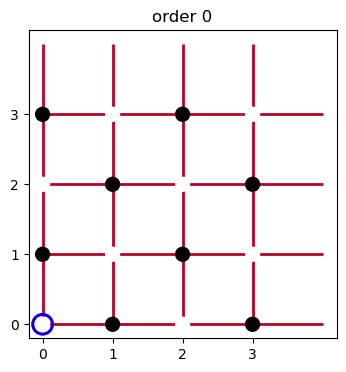

In [17]:
import numpy as np
import matplotlib.pyplot as plt
ver1 = np.array([[1, 1, 1, 1],
                 [1, 1, 1, 1],
                 [1, 1, 1, 1],
                 [1, 1, 1, 1]]) # vertical link
hor1 = np.array([[1, 1, 1, 1],
                 [1, 1, 1, 1],
                 [1, 1, 1, 1],
                 [1, 1, 1, 1]]) # horizontal link 
num = np.array([[0,1,0,1],
                [1,0,1,0],
                [0,1,0,1],
                [1,0,1,0]]) # site occupation

binary1 = converter_f2s('file2binary', [num, hor1, ver1], 1) # convert to binary string
'''
the string has the order
// |     |     
// 5     11    
// |     |     
// 3--4--9--10--
// |     |     
// 2     8     
// |     |     
// 0--1--6--7--
'''

# find all reachable basis (will modify this latter)
b = generate_all_reachable_configs(initial_state=binary1, Lx = 4, Ly =4, S =1, conserveenergy=False, dynamics='both', m=m, g=g, ev=np.inf, pbc = False)
basis,n =  basis_generator(binary1, Lx=4, Ly=4, m=0, g=0, ev = np.inf, dynamics='both',  S=1, pbc = False)

t = 10




import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

vl = []
hl = []
nl = []
text = []

a = sorted(b, key=lambda x: x[1])

# === Generate v,h link values for each state ===
for binary2, order in a[:1]:
    n1, fv1, fh1 = converter_b2f(binary2, ly=4, lx=4, s = 1)
    vl.append(fv1)
    hl.append(fh1)
    nl.append(n1)
    text.append(order)

# === Determine grid layout ===
nplots = len(text)
ncols = int(np.ceil(np.sqrt(nplots)))
nrows = int(np.ceil(nplots / ncols))

# === Create figure and subplots ===
fig = plt.figure(figsize=(4*ncols, 4*nrows))
gs = gridspec.GridSpec(nrows, ncols, hspace=0.1, wspace=0.1)

# === Plot each generated pattern ===
for idx in range(nplots):
    ax = fig.add_subplot(gs[idx // ncols, idx % ncols])
    plot_lattice_fermion(
        ax=ax,
        Lx=4,
        Ly=4,       
        site_val=nl[idx],
        link_values_x=hl[idx],
        link_values_y=vl[idx],
        t="/",
        J="/",
        m="/",
        g="/",
        chi="/",
        pp=[0,0],
        pe=[0,0],
        s = 1
    )
    ax.set_title(f'order {text[idx]}')
plt.show()

In [18]:
H_boson = ham(basis,
        n,
        Lx=Lx_value,
        Ly=Ly_value,
        m=0.75,
        J=0,
        t=t_value,
        g=g_value,
        ev=np.inf,
        fermion=True,
        S=1,
        pbc=False,
        )

H_fermion = ham(basis,
        n,
        Lx=Lx_value,
        Ly=Ly_value,
        m=0.75,
        J=0,
        t=t_value,
        g=g_value,
        ev=np.inf,
        fermion=True,
        S=1,
        pbc=False,
        )

NameError: name 'Lx_value' is not defined